# Прогнозирование одного временного ряда: BTC-USD

## 1. Установка библиотек

In [1]:
import os

import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch.utils.data import DataLoader, TensorDataset

from transformers import (
    AutoformerConfig,
    AutoformerForPrediction,
    InformerConfig,
    InformerForPrediction,
    PatchTSTConfig,
    PatchTSTForPrediction,
)


SEED = 42

W0610 14:26:35.241000 14941 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0610 14:26:35.270000 14941 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## 2. Загрузка BTC-USD через yfinance

Берем только `Close`. 

В реальной задаче можно использовать:

- `Open`, `High`, `Low`, `Close`;
- `Volume`;
- календарные признаки;
- данные других активов;
- макроэкономические признаки.

In [10]:
TICKER = "BTC-USD"
START_DATE = "2018-01-01"

raw = yf.download(TICKER, start=START_DATE, auto_adjust=True, progress=False)
raw = raw.dropna().sort_index()

series = raw[["Close"]].copy()
series.columns = ["close"]

print(series.head())
print(series.tail())
print(series.shape)

                   close
Date                    
2018-01-01  13657.200195
2018-01-02  14982.099609
2018-01-03  15201.000000
2018-01-04  15599.200195
2018-01-05  17429.500000
                   close
Date                    
2026-06-06  60867.414062
2026-06-07  63239.519531
2026-06-08  63090.589844
2026-06-09  61643.781250
2026-06-10  61164.671875
(3083, 1)


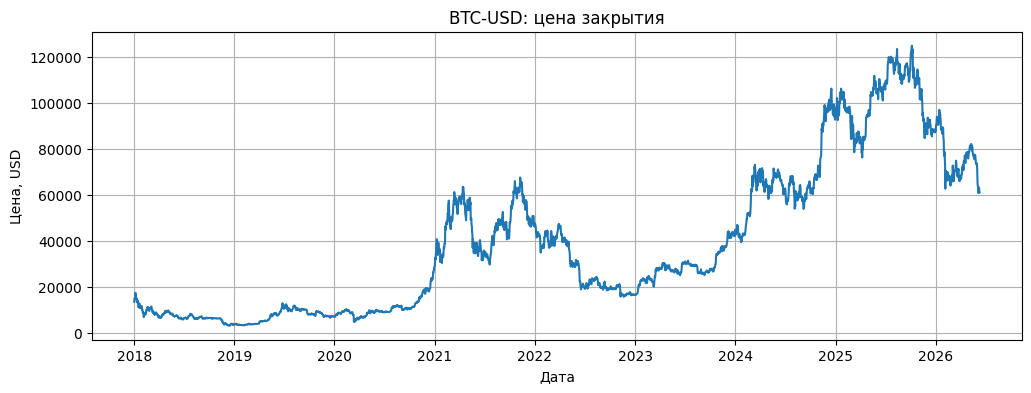

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(series.index, series["close"])
plt.title("BTC-USD: цена закрытия")
plt.xlabel("Дата")
plt.ylabel("Цена, USD")
plt.grid(True)
plt.show()

## 3. Temporal split

Делим ряд по времени:

- 70% train;
- 15% validation;
- 15% test.

Validation используется для ранней остановки и выбора модели.
Test используется только для финального сравнения.

In [12]:
def temporal_split(frame, train_size=0.70, val_size=0.15):
    """
    Делит DataFrame на train, validation и test по времени.

    Аргументы:
        frame: DataFrame, отсортированный по дате.
        train_size: доля train.
        val_size: доля validation.

    Возвращает:
        train, validation, test.
    """
    n = len(frame)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))

    train = frame.iloc[:train_end].copy()
    validation = frame.iloc[train_end:val_end].copy()
    test = frame.iloc[val_end:].copy()

    return train, validation, test


train_df, val_df, test_df = temporal_split(series)

print(train_df.index.min(), train_df.index.max(), train_df.shape)
print(val_df.index.min(), val_df.index.max(), val_df.shape)
print(test_df.index.min(), test_df.index.max(), test_df.shape)

2018-01-01 00:00:00 2023-11-28 00:00:00 (2158, 1)
2023-11-29 00:00:00 2025-03-04 00:00:00 (462, 1)
2025-03-05 00:00:00 2026-06-10 00:00:00 (463, 1)


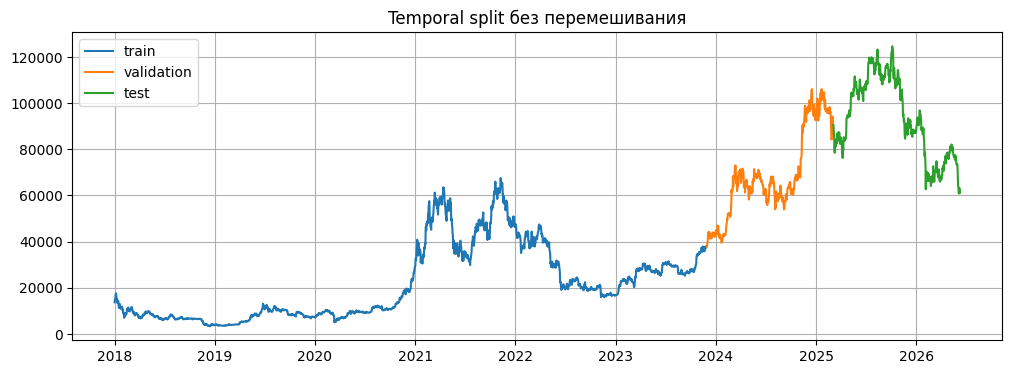

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(train_df.index, train_df["close"], label="train")
plt.plot(val_df.index, val_df["close"], label="validation")
plt.plot(test_df.index, test_df["close"], label="test")
plt.title("Temporal split без перемешивания")
plt.legend()
plt.grid(True)
plt.show()

## 4. Масштабирование без утечки будущего

Scaler обучается только на `train`.

Потом тот же scaler применяется к `validation` и `test`.

Это важно: если обучить scaler на всем ряде, статистики будущего попадут в train pipeline.

In [14]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["close"]])
val_scaled = scaler.transform(val_df[["close"]])
test_scaled = scaler.transform(test_df[["close"]])

scaled_full = np.concatenate([train_scaled, val_scaled, test_scaled], axis=0)

train_end = len(train_scaled)
val_end = len(train_scaled) + len(val_scaled)

print(scaled_full.shape)

(3083, 1)


## 5. Sliding windows

Каждый пример:

- вход: последние `CONTEXT_LENGTH` значений;
- target: следующие `PREDICTION_LENGTH` значений.

Для test окон начало контекста может попадать в validation, потому что в реальном прогнозе у нас есть вся история до момента прогноза. Но target test-окон находится только в test-периоде.

## 6. Метрики и обратное масштабирование

Оцениваем прогноз в исходных долларах.

Метрики:

$$
MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|,
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}.
$$

In [15]:
def inverse_close(values):
    """
    Возвращает значения close из стандартизированного масштаба в USD.

    Аргументы:
        values: массив любой формы.

    Возвращает:
        Массив той же формы в исходном масштабе.
    """
    original_shape = values.shape
    flat = values.reshape(-1, 1)
    inverted = scaler.inverse_transform(flat).reshape(original_shape)
    return inverted


def evaluate_forecast(y_true, y_pred, model_name):
    """
    Calculates RMSE and MAE for the forecast.
    """
    # Ensure shapes match
    if y_true.shape != y_pred.shape:
        min_len = min(len(y_true), len(y_pred))
        y_true = y_true[:min_len]
        y_pred = y_pred[:min_len]
        
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    
    return {
        "Model": model_name,
        "RMSE": float(rmse),
        "MAE": float(mae)
    }


def plot_one_forecast(y_true_scaled, y_pred_scaled, title, sample_id=0):
    """
    Рисует один пример прогноза.

    Аргументы:
        y_true_scaled: истинные значения.
        y_pred_scaled: прогноз.
        title: заголовок графика.
        sample_id: номер тестового окна.
    """
    true_values = inverse_close(y_true_scaled[sample_id])
    pred_values = inverse_close(y_pred_scaled[sample_id])

    plt.figure(figsize=(8, 4))
    plt.plot(true_values, marker="o", label="true")
    plt.plot(pred_values, marker="o", label="forecast")
    plt.title(title)
    plt.xlabel("Шаг прогноза")
    plt.ylabel("Close, USD")
    plt.legend()
    plt.grid(True)
    plt.show()

# Hugging Face Transformers для временных рядов

`Autoformer`, `Informer` и `PatchTST` в библиотеке `transformers` — это специализированные архитектуры для time series forecasting.

В этом блокноте мы обучаем их с нуля на окнах BTC-USD.

Особенность Autoformer/Informer: им нужны лаги, поэтому фактическая длина `past_values` равна:

$$
C + \max(\text{lags}).
$$

In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONTEXT_LENGTH = 90
PREDICTION_LENGTH = 14
BATCH_SIZE = 32
EPOCHS = 20

def make_time_features(length):
    """
    Создает простые временные признаки для каждого шага.

    Аргументы:
        length: длина ряда.

    Возвращает:
        Массив формы (length, 2): sin/cos недельного цикла.
    """
    steps = np.arange(length)
    sin_week = np.sin(2 * np.pi * steps / 7)
    cos_week = np.cos(2 * np.pi * steps / 7)
    return np.stack([sin_week, cos_week], axis=-1).astype("float32")


time_features = make_time_features(len(scaled_full))
LAGS = [1, 2, 3, 7]
HF_PAST_LENGTH = CONTEXT_LENGTH + max(LAGS)

In [17]:
def make_hf_windows(values, time_features, context_length, prediction_length, lags, start_target, end_target):
    """
    Creates windows for Autoformer/Informer.
    NOTE: Values and masks must be 2D (Batch, Seq) for HF models.
    """
    past_values, future_values = [], []
    past_tf, future_tf = [], []
    past_mask = []

    past_length = context_length + max(lags)

    for target_start in range(start_target, end_target - prediction_length + 1):
        past_start = target_start - past_length
        if past_start < 0:
            continue

        # Slice data
        p_val = values[past_start:target_start]
        f_val = values[target_start:target_start + prediction_length]
        
        # Remove the last dimension if it exists (convert [Seq, 1] to [Seq])
        if p_val.ndim > 1:
            p_val = p_val.squeeze(-1)
            f_val = f_val.squeeze(-1)

        past_values.append(p_val)
        future_values.append(f_val)
        
        past_tf.append(time_features[past_start:target_start])
        future_tf.append(time_features[target_start:target_start + prediction_length])
        
        # Create mask and remove last dimension
        mask = np.ones_like(p_val)
        past_mask.append(mask)

    return TensorDataset(
        torch.tensor(np.asarray(past_values), dtype=torch.float32),   # Shape: [Batch, Seq]
        torch.tensor(np.asarray(future_values), dtype=torch.float32), # Shape: [Batch, Seq]
        torch.tensor(np.asarray(past_tf), dtype=torch.float32),       # Shape: [Batch, Seq, NumFeatures]
        torch.tensor(np.asarray(future_tf), dtype=torch.float32),     # Shape: [Batch, Seq, NumFeatures]
        torch.tensor(np.asarray(past_mask), dtype=torch.float32),     # Shape: [Batch, Seq]
    )


hf_train = make_hf_windows(scaled_full, time_features, CONTEXT_LENGTH, PREDICTION_LENGTH, LAGS, HF_PAST_LENGTH, train_end)
hf_val = make_hf_windows(scaled_full, time_features, CONTEXT_LENGTH, PREDICTION_LENGTH, LAGS, train_end, val_end)
hf_test = make_hf_windows(scaled_full, time_features, CONTEXT_LENGTH, PREDICTION_LENGTH, LAGS, val_end, len(scaled_full))

hf_train_loader = DataLoader(hf_train, batch_size=32, shuffle=True)
hf_val_loader = DataLoader(hf_val, batch_size=32)
hf_test_loader = DataLoader(hf_test, batch_size=32)

In [18]:
def build_hf_seq_model(model_name):
    """
    Строит Autoformer или Informer.
    """
    config_kwargs = dict(
        prediction_length=PREDICTION_LENGTH,
        context_length=CONTEXT_LENGTH,
        lags_sequence=LAGS,
        input_size=1,
        num_time_features=2,
        num_static_categorical_features=0,
        num_static_real_features=0,
        d_model=32,
        encoder_layers=2,
        decoder_layers=1,
        encoder_attention_heads=2,
        decoder_attention_heads=2,
        dropout=0.1,
    )

    if model_name == "Autoformer":
        config = AutoformerConfig(**config_kwargs)
        return AutoformerForPrediction(config)

    if model_name == "Informer":
        config = InformerConfig(**config_kwargs)
        return InformerForPrediction(config)

    raise ValueError(model_name)


def train_hf_seq_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    """
    Обучает Autoformer/Informer.
    """
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for past_values, future_values, past_tf, future_tf, past_mask in train_loader:
            past_values = past_values.to(DEVICE)
            future_values = future_values.to(DEVICE)
            past_tf = past_tf.to(DEVICE)
            future_tf = future_tf.to(DEVICE)
            past_mask = past_mask.to(DEVICE)

            optimizer.zero_grad()
            output = model(
                past_values=past_values,
                future_values=future_values,
                past_time_features=past_tf,
                future_time_features=future_tf,
                past_observed_mask=past_mask,
            )
            loss = output.loss
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for past_values, future_values, past_tf, future_tf, past_mask in val_loader:
                output = model(
                    past_values=past_values.to(DEVICE),
                    future_values=future_values.to(DEVICE),
                    past_time_features=past_tf.to(DEVICE),
                    future_time_features=future_tf.to(DEVICE),
                    past_observed_mask=past_mask.to(DEVICE),
                )
                val_losses.append(float(output.loss.detach().cpu()))

        print(f"epoch={epoch}, train_loss={np.mean(train_losses):.4f}, val_loss={np.mean(val_losses):.4f}")

    return model

In [19]:
def predict_hf_seq_model(model, loader):
    """
    Получает прогноз Autoformer/Informer через generate.
    """
    model.eval()
    predictions = []

    with torch.no_grad():
        for past_values, future_values, past_tf, future_tf, past_mask in loader:
            generated = model.generate(
                past_values=past_values.to(DEVICE),
                past_time_features=past_tf.to(DEVICE),
                future_time_features=future_tf.to(DEVICE),
                past_observed_mask=past_mask.to(DEVICE),
            )
            seq = generated.sequences
            seq = seq.mean(dim=1)
            predictions.append(seq.detach().cpu().numpy())

    pred = np.concatenate(predictions, axis=0)
    return pred.squeeze(-1) if pred.ndim == 3 else pred


y_test_tensor = hf_test.tensors[1]
y_test = y_test_tensor.numpy()
if y_test.ndim == 3:
    y_test = y_test.squeeze(-1)
# ----------------------

hf_results = []
hf_predictions = {}

for model_name in ["Autoformer", "Informer"]:
    print("\n", "=" * 80)
    print(model_name)
    
    # Build and Train
    hf_model = build_hf_seq_model(model_name)
    hf_model = train_hf_seq_model(hf_model, hf_train_loader, hf_val_loader, epochs=5, lr=1e-3)
    
    # Predict
    pred = predict_hf_seq_model(hf_model, hf_test_loader)
    hf_predictions[model_name] = pred
    
    # Evaluate
    hf_results.append(evaluate_forecast(y_test[:len(pred)], pred, model_name))

pd.DataFrame(hf_results)


Autoformer
epoch=1, train_loss=1.2289, val_loss=2.9058
epoch=2, train_loss=0.8746, val_loss=2.2631
epoch=3, train_loss=0.4440, val_loss=1.5767
epoch=4, train_loss=0.2743, val_loss=1.3199
epoch=5, train_loss=0.1560, val_loss=1.1115

Informer
epoch=1, train_loss=0.8608, val_loss=1.6349
epoch=2, train_loss=-0.1267, val_loss=0.5845
epoch=3, train_loss=-0.5459, val_loss=0.3660
epoch=4, train_loss=-0.7101, val_loss=0.0795
epoch=5, train_loss=-0.7571, val_loss=-0.0101


,Model,RMSE,MAE
0,Autoformer,1.097920,0.897718
1,Informer,0.671283,0.525438


## PatchTST

PatchTST разбивает временной ряд на патчи и применяет Transformer к последовательности патчей.

В отличие от Autoformer/Informer, здесь используем обычную длину контекста `CONTEXT_LENGTH`.

In [30]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from transformers import PatchTSTConfig, PatchTSTForPrediction

# --- 1. Функция создания окон специально для PatchTST (длина ровно CONTEXT_LENGTH) ---
def make_patchtst_windows(values, context_length, prediction_length, start_target, end_target):
    """
    Создает окна для PatchTST.
    Важно: past_length равен ровно context_length (без добавления лагов).
    """
    past_values_list, future_values_list = [], []
    
    for target_start in range(start_target, end_target - prediction_length + 1):
        past_start = target_start - context_length
        if past_start < 0:
            continue

        # Берем срезы
        p_val = values[past_start:target_start]
        f_val = values[target_start:target_start + prediction_length]
        
        # Убираем лишнее измерение канала, если оно есть ([Seq, 1] -> [Seq])
        if p_val.ndim > 1:
            p_val = p_val.squeeze(-1)
            f_val = f_val.squeeze(-1)

        past_values_list.append(p_val)
        future_values_list.append(f_val)

    # Возвращаем тензоры формы [N, Seq]
    return TensorDataset(
        torch.tensor(np.asarray(past_values_list), dtype=torch.float32),
        torch.tensor(np.asarray(future_values_list), dtype=torch.float32)
    )

# --- 2. Создание датасетов с правильной длиной (90) ---
print("Создание окон для PatchTST (Context Length = 90)...")

patch_train_ds_raw = make_patchtst_windows(scaled_full, CONTEXT_LENGTH, PREDICTION_LENGTH, HF_PAST_LENGTH, train_end)
patch_val_ds_raw = make_patchtst_windows(scaled_full, CONTEXT_LENGTH, PREDICTION_LENGTH, train_end, val_end)
patch_test_ds_raw = make_patchtst_windows(scaled_full, CONTEXT_LENGTH, PREDICTION_LENGTH, val_end, len(scaled_full))

# --- 3. Добавление измерения канала [B, Seq] -> [B, Seq, 1] ---
def add_channel_dim(dataset):
    X = dataset.tensors[0].unsqueeze(-1) # [B, Seq, 1]
    y = dataset.tensors[1].unsqueeze(-1) # [B, PredLen, 1]
    return TensorDataset(X, y)

patch_train_ds = add_channel_dim(patch_train_ds_raw)
patch_val_ds = add_channel_dim(patch_val_ds_raw)
patch_test_ds = add_channel_dim(patch_test_ds_raw)

# Проверка формы
sample_x, sample_y = next(iter(DataLoader(patch_train_ds, batch_size=1)))
print(f"Проверка формы входа: {sample_x.shape} (должно быть [1, 90, 1])")

# --- 4. Загрузчики данных ---
patch_train_loader = DataLoader(patch_train_ds, batch_size=BATCH_SIZE, shuffle=True)
patch_val_loader = DataLoader(patch_val_ds, batch_size=BATCH_SIZE)
patch_test_loader = DataLoader(patch_test_ds, batch_size=BATCH_SIZE)

# --- 5. Конфигурация и инициализация модели ---
patch_config = PatchTSTConfig(
    context_length=CONTEXT_LENGTH,      # 90
    prediction_length=PREDICTION_LENGTH,# 14
    num_input_channels=1,               # 1 канал
    patch_length=16,                    # Длина патча
    patch_stride=8,                     # Шаг патча
    d_model=64,                         # Скрытая размерность
    num_hidden_layers=2,                # Слои энкодера
    num_attention_heads=4,              # Головы внимания
    dropout=0.1,
    head_dropout=0.1,
)

patch_model = PatchTSTForPrediction(patch_config).to(DEVICE)
print(f"Модель PatchTST инициализирована на {DEVICE}")

# --- 6. Функции обучения и предсказания ---
def train_patchtst(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for past_values, future_values in train_loader:
            optimizer.zero_grad()
            output = model(
                past_values=past_values.to(DEVICE),
                future_values=future_values.to(DEVICE),
            )
            loss = output.loss
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for past_values, future_values in val_loader:
                output = model(
                    past_values=past_values.to(DEVICE),
                    future_values=future_values.to(DEVICE),
                )
                val_losses.append(float(output.loss.detach().cpu()))

        print(f"epoch={epoch}, train_loss={np.mean(train_losses):.4f}, val_loss={np.mean(val_losses):.4f}")
    return model

def predict_patchtst(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for past_values, future_values in loader:
            output = model(past_values=past_values.to(DEVICE))
            pred = output.prediction_outputs # [B, PredLen, 1]
            predictions.append(pred.detach().cpu().numpy())
    
    pred = np.concatenate(predictions, axis=0)
    if pred.ndim == 3:
        pred = pred.squeeze(-1) # [B, PredLen]
    return pred

# --- 7. Запуск обучения и оценки ---
print("\n", "=" * 80)
print("Запуск PatchTST")

# Обучение
patch_model = train_patchtst(patch_model, patch_train_loader, patch_val_loader, epochs=5, lr=1e-3)

# Прогноз
patch_pred = predict_patchtst(patch_model, patch_test_loader)

# Сохранение и оценка
hf_predictions["PatchTST"] = patch_pred

# Убедимся, что y_test определен (из предыдущих шагов)
if 'y_test' not in globals():
    y_test_tensor = hf_test.tensors[1]
    y_test = y_test_tensor.numpy().squeeze(-1)

hf_results.append(evaluate_forecast(y_test[:len(patch_pred)], patch_pred, "PatchTST"))

print("\nИтоговые результаты:")
display(pd.DataFrame(hf_results))

Создание окон для PatchTST (Context Length = 90)...
Проверка формы входа: torch.Size([1, 90, 1]) (должно быть [1, 90, 1])
Модель PatchTST инициализирована на cuda

Запуск PatchTST
epoch=1, train_loss=0.0610, val_loss=0.1330
epoch=2, train_loss=0.0420, val_loss=0.1784
epoch=3, train_loss=0.0379, val_loss=0.1462
epoch=4, train_loss=0.0380, val_loss=0.1564
epoch=5, train_loss=0.0424, val_loss=0.2460

Итоговые результаты:


,Model,RMSE,MAE
0,Autoformer,1.097920,0.897718
1,Informer,0.671283,0.525438
2,PatchTST,0.382327,0.291117
